# SNR-aware evaluation

This notebook evaluates the selected Random Forest classifier as a
function of signal-to-noise ratio (SNR).

The classifier uses the full 28-feature representation and is trained
on the complete training split.

The test set remains untouched.

In [24]:
from pathlib import Path
import pickle
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support

sys.path.append(str(Path("../src").resolve()))

from rfml.features import build_feature_table

## 1. Data loading

In [25]:
DATA_PATH = Path(
    "../data/raw/RML2016.10a/RML2016.10a_dict.pkl"
)

PROCESSED_DIR = Path("../data/processed")

with open(DATA_PATH, "rb") as f:
    radioml = pickle.load(f, encoding="latin1")

train_metadata = pd.read_csv(
    PROCESSED_DIR / "train_metadata.csv"
)

validation_metadata = pd.read_csv(
    PROCESSED_DIR / "validation_metadata.csv"
)

print("Train:", train_metadata.shape)
print("Validation:", validation_metadata.shape)

Train: (154000, 4)
Validation: (33000, 4)


## 2. Full feature extraction

In [3]:
start = time.perf_counter()

train_features_full = build_feature_table(
    radioml,
    train_metadata,
    feature_set="full"
)

train_feature_time = time.perf_counter() - start

print("Train features:", train_features_full.shape)
print(
    f"Feature extraction time: "
    f"{train_feature_time:.2f} seconds"
)

Train features: (154000, 31)
Feature extraction time: 768.46 seconds


In [4]:
start = time.perf_counter()

validation_features_full = build_feature_table(
    radioml,
    validation_metadata,
    feature_set="full"
)

validation_feature_time = time.perf_counter() - start

print(
    "Validation features:",
    validation_features_full.shape
)

print(
    f"Feature extraction time: "
    f"{validation_feature_time:.2f} seconds"
)

Validation features: (33000, 31)
Feature extraction time: 154.85 seconds


In [5]:
train_features_full.to_pickle(
    PROCESSED_DIR / "train_full_features.pkl"
)

validation_features_full.to_pickle(
    PROCESSED_DIR / "validation_full_features.pkl"
)

print("✅ Full feature tables cached.")

✅ Full feature tables cached.


In [6]:
metadata_columns = [
    "sample_id",
    "modulation",
    "snr"
]

feature_columns = [
    column
    for column in train_features_full.columns
    if column not in metadata_columns
]

X_train = train_features_full[feature_columns]
y_train = train_features_full["modulation"]

X_validation = validation_features_full[
    feature_columns
]

y_validation = validation_features_full[
    "modulation"
]

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("Features:", len(feature_columns))

X_train: (154000, 28)
X_validation: (33000, 28)
Features: 28


In [7]:
final_candidate_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start = time.perf_counter()

final_candidate_rf.fit(
    X_train,
    y_train
)

training_time = time.perf_counter() - start

print(
    f"Training time: {training_time:.2f} seconds"
)

Training time: 49.81 seconds


In [8]:
validation_predictions = final_candidate_rf.predict(
    X_validation
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro"
)

print("Random Forest — full training split")
print(f"Accuracy: {validation_accuracy:.4f}")
print(f"Macro-F1: {validation_f1:.4f}")

Random Forest — full training split
Accuracy: 0.5314
Macro-F1: 0.5493


In [9]:
evaluation_df = pd.DataFrame({
    "true_modulation": y_validation.to_numpy(),
    "predicted_modulation": validation_predictions,
    "snr": validation_features_full["snr"].to_numpy()
})

evaluation_df.head()

,true_modulation,predicted_modulation,snr
0,QAM64,BPSK,-14
1,AM-DSB,AM-DSB,-4
2,AM-DSB,AM-DSB,-4
3,WBFM,WBFM,-18
4,BPSK,PAM4,0


In [10]:
snr_results = []

for snr in sorted(evaluation_df["snr"].unique()):

    snr_data = evaluation_df[
        evaluation_df["snr"] == snr
    ]

    snr_accuracy = accuracy_score(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"]
    )

    snr_f1 = f1_score(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"],
        average="macro"
    )

    snr_results.append({
        "snr": snr,
        "accuracy": snr_accuracy,
        "macro_f1": snr_f1
    })

snr_results_df = pd.DataFrame(snr_results)

snr_results_df

,snr,accuracy,macro_f1
0,-20,0.094545,0.029284
1,-18,0.093939,0.027055
2,-16,0.098788,0.039194
3,-14,0.112727,0.061423
4,-12,0.143030,0.101718
5,-10,0.198788,0.165009
6,-8,0.292121,0.262428
7,-6,0.422424,0.387568
8,-4,0.489091,0.470797
9,-2,0.597576,0.588219


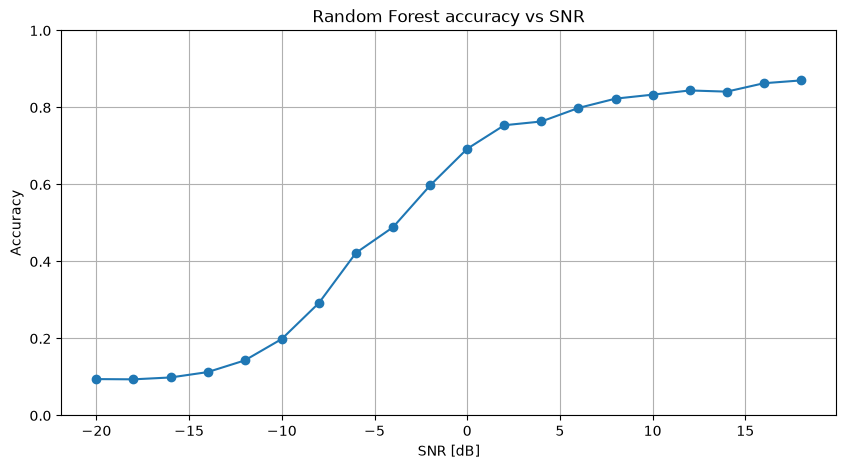

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    snr_results_df["snr"],
    snr_results_df["accuracy"],
    marker="o"
)

ax.set_title("Random Forest accuracy vs SNR")
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True)

plt.show()

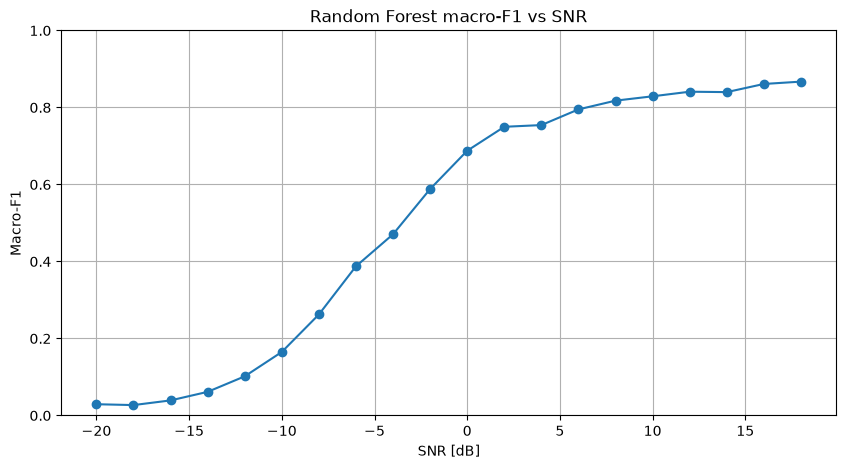

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    snr_results_df["snr"],
    snr_results_df["macro_f1"],
    marker="o"
)

ax.set_title("Random Forest macro-F1 vs SNR")
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.grid(True)

plt.show()  

## Confusion matrices at representative SNR levels

Confusion matrices are analyzed at low, medium and high SNR conditions
to identify which modulation classes are confused as signal quality
improves.

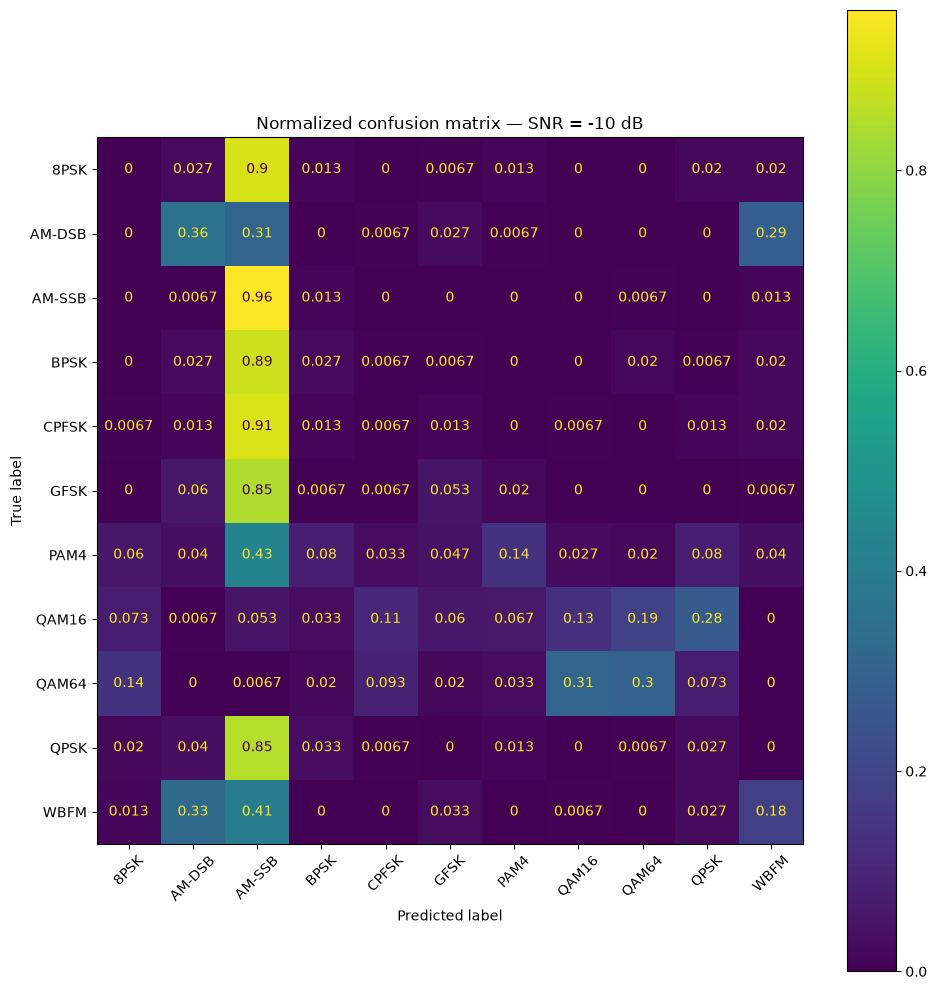

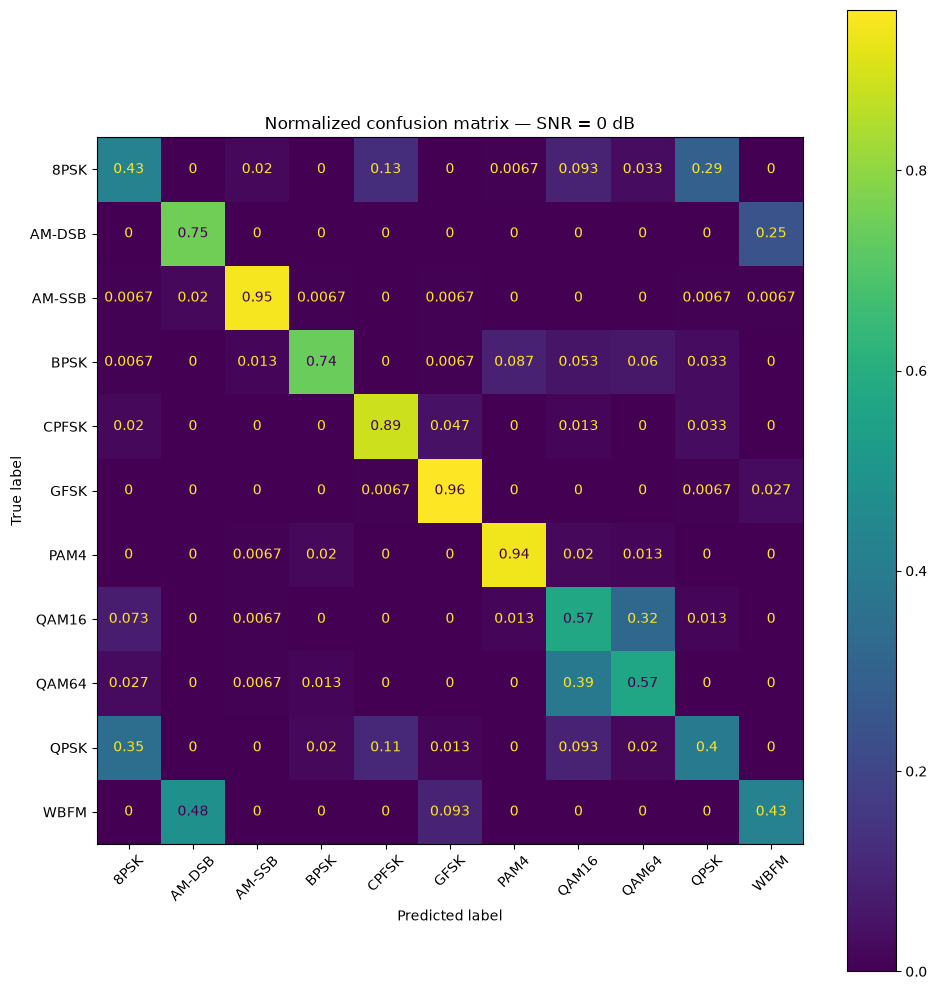

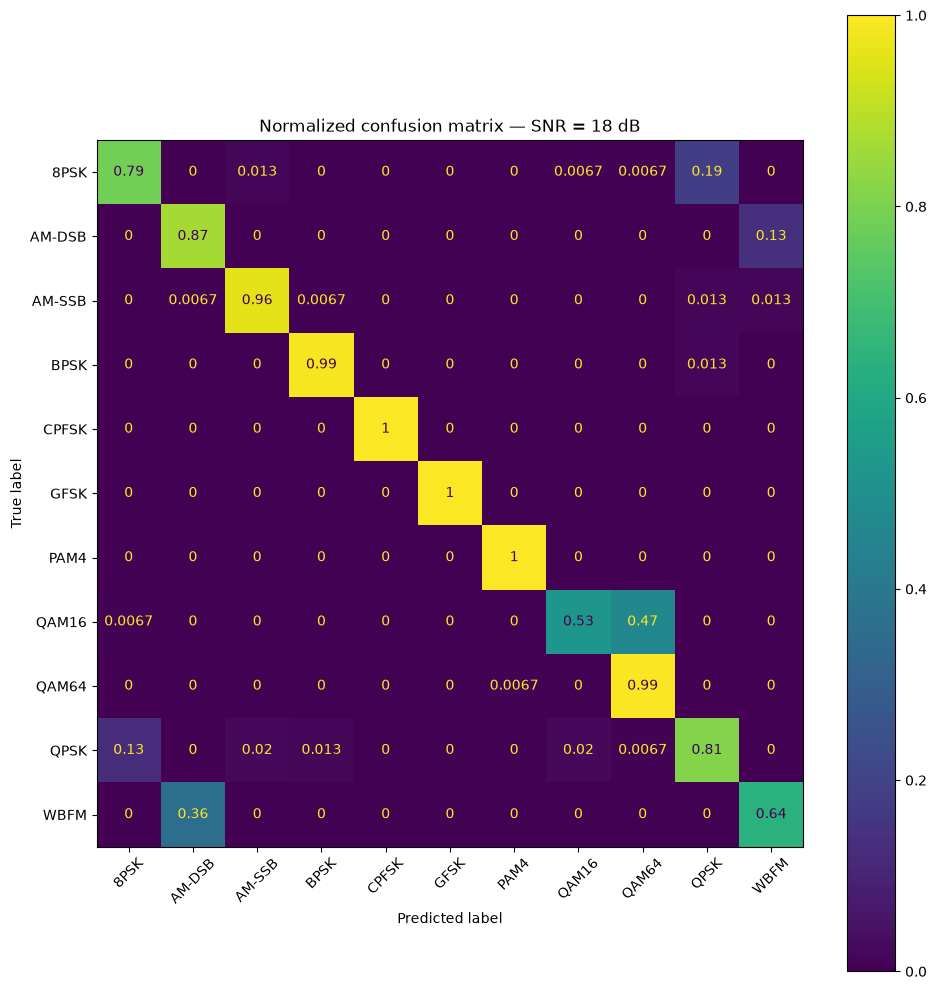

In [14]:
snr_levels = [-10, 0, 18]

for snr in snr_levels:

    snr_data = evaluation_df[
        evaluation_df["snr"] == snr
    ]

    fig, ax = plt.subplots(figsize=(10, 10))

    ConfusionMatrixDisplay.from_predictions(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"],
        normalize="true",
        xticks_rotation=45,
        ax=ax
    )

    ax.set_title(
        f"Normalized confusion matrix — SNR = {snr} dB"
    )

    plt.tight_layout()
    plt.show()

## Per-class performance across SNR

Per-class metrics are evaluated at every SNR level to determine which
modulations become distinguishable first as signal quality improves.

In [16]:
classes = sorted(
    evaluation_df["true_modulation"].unique()
)

class_snr_results = []

for snr in sorted(evaluation_df["snr"].unique()):

    snr_data = evaluation_df[
        evaluation_df["snr"] == snr
    ]

    precision, recall, f1, _ = precision_recall_fscore_support(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"],
        labels=classes,
        zero_division=0
    )

    for i, modulation in enumerate(classes):
        class_snr_results.append({
            "snr": snr,
            "modulation": modulation,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i]
        })

class_snr_df = pd.DataFrame(
    class_snr_results
)

class_snr_df.head()

,snr,modulation,precision,recall,f1
0,-20,8PSK,0.000000,0.000000,0.000000
1,-20,AM-DSB,0.100000,0.026667,0.042105
2,-20,AM-SSB,0.093220,0.953333,0.169834
3,-20,BPSK,0.090909,0.006667,0.012422
4,-20,CPFSK,0.000000,0.000000,0.000000


In [17]:
recall_matrix = class_snr_df.pivot(
    index="modulation",
    columns="snr",
    values="recall"
)

recall_matrix.round(2)

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,0.00,0.00,0.00,0.01,0.00,0.00,0.03,0.05,0.10,0.24,0.43,0.66,0.65,0.71,0.74,0.76,0.77,0.83,0.81,0.79
AM-DSB,0.03,0.03,0.08,0.11,0.25,0.36,0.35,0.54,0.67,0.71,0.75,0.77,0.91,0.88,0.95,0.91,0.95,0.84,0.91,0.87
AM-SSB,0.95,0.96,0.93,0.94,0.93,0.96,0.95,0.95,0.93,0.97,0.95,0.97,0.90,0.94,0.93,0.91,0.95,0.95,0.95,0.96
BPSK,0.01,0.01,0.02,0.03,0.00,0.03,0.04,0.11,0.29,0.53,0.74,0.87,0.96,0.94,0.99,0.97,1.00,0.96,0.97,0.99
CPFSK,0.00,0.00,0.00,0.00,0.00,0.01,0.04,0.16,0.37,0.64,0.89,0.97,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
GFSK,0.01,0.00,0.00,0.01,0.01,0.05,0.22,0.58,0.75,0.88,0.96,0.97,0.99,0.99,0.99,1.00,1.00,0.99,1.00,1.00
PAM4,0.00,0.01,0.00,0.02,0.01,0.14,0.45,0.65,0.79,0.90,0.94,0.97,0.98,0.97,0.97,0.99,0.97,0.97,0.97,1.00
QAM16,0.00,0.00,0.01,0.00,0.02,0.13,0.19,0.42,0.42,0.44,0.57,0.57,0.61,0.51,0.64,0.69,0.59,0.65,0.65,0.53
QAM64,0.01,0.00,0.01,0.12,0.21,0.30,0.51,0.63,0.50,0.57,0.57,0.63,0.53,0.64,0.63,0.61,0.59,0.64,0.83,0.99


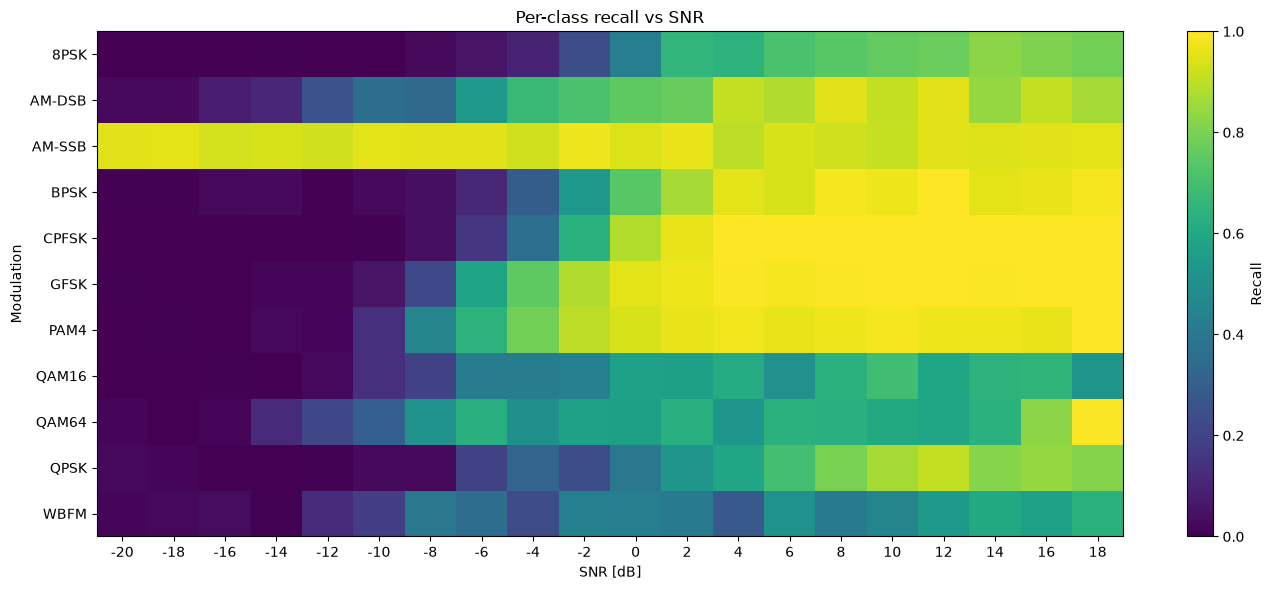

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    recall_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(recall_matrix.columns))
)

ax.set_xticklabels(
    recall_matrix.columns
)

ax.set_yticks(
    range(len(recall_matrix.index))
)

ax.set_yticklabels(
    recall_matrix.index
)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Modulation")
ax.set_title("Per-class recall vs SNR")

fig.colorbar(
    image,
    ax=ax,
    label="Recall"
)

plt.tight_layout()
plt.show()

In [19]:
f1_matrix = class_snr_df.pivot(
    index="modulation",
    columns="snr",
    values="f1"
)

f1_matrix.round(2)

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,0.00,0.00,0.00,0.01,0.00,0.00,0.04,0.07,0.14,0.29,0.45,0.63,0.63,0.71,0.76,0.80,0.82,0.84,0.82,0.82
AM-DSB,0.04,0.04,0.13,0.15,0.31,0.38,0.35,0.48,0.57,0.65,0.67,0.68,0.70,0.76,0.75,0.75,0.80,0.75,0.77,0.78
AM-SSB,0.17,0.17,0.17,0.18,0.20,0.25,0.34,0.60,0.91,0.97,0.95,0.95,0.93,0.92,0.95,0.94,0.96,0.93,0.95,0.96
BPSK,0.01,0.01,0.04,0.04,0.00,0.04,0.06,0.15,0.38,0.65,0.82,0.91,0.94,0.94,0.98,0.97,0.99,0.95,0.97,0.98
CPFSK,0.00,0.00,0.00,0.00,0.00,0.01,0.06,0.21,0.38,0.58,0.83,0.95,1.00,0.99,0.99,0.99,1.00,0.99,1.00,1.00
GFSK,0.01,0.00,0.00,0.02,0.02,0.08,0.27,0.54,0.71,0.82,0.90,0.92,0.95,0.95,0.97,0.98,0.98,0.98,0.98,1.00
PAM4,0.00,0.01,0.00,0.04,0.02,0.22,0.57,0.63,0.68,0.84,0.92,0.96,0.98,0.98,0.98,0.97,0.98,0.97,0.97,1.00
QAM16,0.00,0.00,0.01,0.00,0.03,0.18,0.25,0.43,0.37,0.41,0.51,0.56,0.57,0.52,0.63,0.66,0.59,0.64,0.71,0.68
QAM64,0.03,0.00,0.03,0.21,0.33,0.39,0.53,0.54,0.41,0.47,0.56,0.61,0.56,0.63,0.65,0.65,0.61,0.66,0.76,0.80


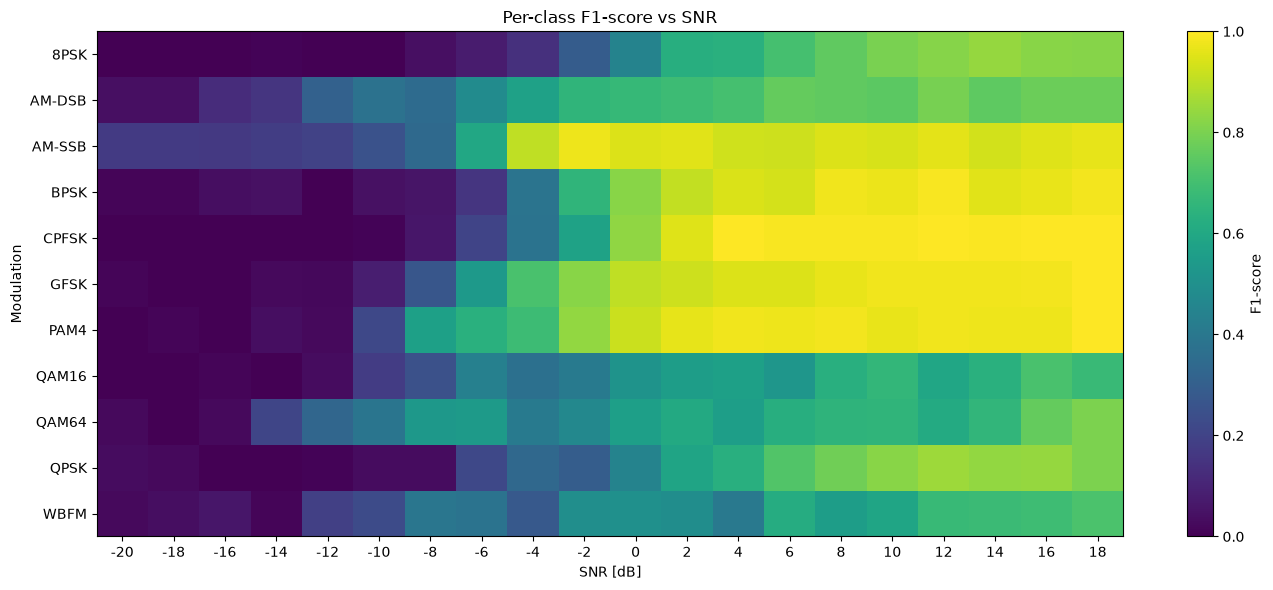

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    f1_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_xticks(range(len(f1_matrix.columns)))
ax.set_xticklabels(f1_matrix.columns)

ax.set_yticks(range(len(f1_matrix.index)))
ax.set_yticklabels(f1_matrix.index)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Modulation")
ax.set_title("Per-class F1-score vs SNR")

fig.colorbar(
    image,
    ax=ax,
    label="F1-score"
)

plt.tight_layout()
plt.show()

In [21]:
snr_results_df.to_csv(
    PROCESSED_DIR / "validation_metrics_by_snr.csv",
    index=False
)

recall_matrix.to_csv(
    PROCESSED_DIR / "validation_recall_by_snr.csv"
)

f1_matrix.to_csv(
    PROCESSED_DIR / "validation_f1_by_snr.csv"
)

print("✅ Validation results saved.")

✅ Validation results saved.


In [22]:
import joblib

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = (
    MODELS_DIR
    / "random_forest_full_features.joblib"
)

joblib.dump(
    final_candidate_rf,
    MODEL_PATH
)

print(
    f"✅ Model saved to: {MODEL_PATH}"
)

✅ Model saved to: ..\models\random_forest_full_features.joblib
